# 🔆 Overview

This notebook takes several steps to generate the final data file that will be used for further model development process:

✅ **imports raw data files**:

There are a total of **six canine data**. We translated the raw data files that were originally in Korean to English for collaboration in advance to importing these data files.

❗**For convenience, the import chunk (beginning of the notebook) and saving chunk (at the end of the notebook) has three file paths for each team members. Before running the whole notebook, comment out the relevant path first.**

⛳ The final test data that we are going to use later will have the same format as these files.

---
✅ **removes duplicates**

👉 There are measures that has duplicate timestamps with some duplicate sets showing diferent glucose levels among the measures. Considering the distribution of the glucose level categories and the team's focus on hypoglycemia, we retain the lowest value among these measures and remove duplicates.

---
✅ **adds columns**:

⭐ glucose, glucose category, normal_range are added *before removing duplicates*

⭐ time_gap, dt_min are added *after removing duplicates*
* **glucose**: level of glucose level obtained from both automatically scanned (record type: 0/historical glucose level) and manually scanned (record type: 1/scan glucose level) glucose levels
* **glucose category**: indicates what group the glucose levels belong to
  * hypoglycemia: glucose level < 65
  * normal : 65 ≤ glucose level ≤ 250
  * hyperglycemia: 250 < glucose level
* **normal_range**: indicates whether the glucose levels are normal or not
  * 1: normal
  * 0: unsafe range (hypoglycemia / hyperglycemia)
* **time_gap**: time gap between the measures
  * we use this variable to split the data into subgroups
* **dt_min**: rate of change in glucose per minute

---
✅ **splits data into subsets**

👉 We see big gaps between the measures that are greater than 15 minutes (the default interval of the device). We conjecture that these gaps come from multiple reasons including device glitch, connection error, changing device, and/or pausing and then resuming monitoring canine glucose levels. To prevent these factors from distorting the data, **we subset the data by splitting when gaps of 60 minutes or greater are observed.** This step results in cases where multiple chunks of time-series come from a single canine data. **Based on the team's aim to predict the 11th data point value using the previous 10 points, we also remove subsets with 10 observations or less.**

---
Meaning of signs
* 🔆: New section
* ⭐: important steps in cleaning
---

# 🔆 Setup

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import os

from matplotlib import pyplot as plt

In [3]:
# display options: show rows up to 50
pd.set_option('display.max_rows', 50)

In [4]:
# mounting on gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 🔆 Importing and Understanding Raw Data Files

## Setting individual paths to 'dataset' folder

**ID - Dog**
* canine1: Buchi-Buchi
* canine2: Bbang-jin
* canine3: Sarang
* canine4: Yeonjoo
* canine5: Jihye
* canine6: Hyeon-Soo

In [6]:
# Ainsley
# data_path = ""

# Ci
# data_path = ""

# WooJung
data_path = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/datasets"

In [8]:
if os.path.exists(data_path):
    print(f"Files in '{data_path}' starting with 'Talk':")
    found_files = [f for f in os.listdir(data_path) if f.startswith('Talk')]
    if found_files:
        for f in found_files:
            print(f)
    else:
        print("No files found starting with 'Talk'.")
else:
    print(f"Directory '{dataset_path}' not found. Please ensure Google Drive is mounted and the path is correct.")

Files in '/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/datasets' starting with 'Talk':
TalkFile_버찌버찌_glucose_canine1.csv
TalkFile_빵진_glucose_canine2.csv
TalkFile_사랑이김_glucose_canine3.csv
TalkFile_연주송_glucose_canine4.csv
TalkFile_지혜김_glucose_canine5.csv
TalkFile_현수김_glucose_canine6.csv


## Getting combned pd dataframe

In [26]:
dfs = []


for filename in found_files:
    full_file_path = os.path.join(data_path, filename)

    # Extract identifier to be 'canine1', 'canine2', etc.
    identifier = filename.split('_glucose_')[1].split('.')[0]

    # Read the file into a DataFrame
    df = pd.read_csv(full_file_path)

    # Add a new column 'ID' (changed name from file_identifier)
    df['ID'] = identifier


    # Append the processed DataFrame to the list
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# sort by ID
combined_df = combined_df.sort_values(by = ["ID"])

print(f"Shape of the combined DataFrame: {combined_df.shape}")
# printing everything because we only have 6 rows
print("Combined DataFrame:")
display(combined_df.groupby("ID").first())

Shape of the combined DataFrame: (38760, 7)
Combined DataFrame:


,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL
ID,,,,,,
canine1,FreeStyle LibreLink,a2e73825-5603-4370-9edc-6941970d3b10,12/2/25 11:50,0,260.0,126.0
canine2,FreeStyle LibreLink,62A42483-61C3-4AC9-A34E-059DA2BC3735,4/17/25 2:58,0,257.0,114.0
canine3,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,6/5/25 6:02,1,406.0,500.0
canine4,FreeStyle LibreLink,3689d896-77d3-4df0-9ac5-55b436d78db5,4/18/25 2:46,0,232.0,165.0
canine5,FreeStyle LibreLink,E9A0CE98-AA19-4E58-8F27-31A26580354B,3/27/25 14:22,1,500.0,416.0
canine6,FreeStyle LibreLink,e7ddfae7-5081-4ed3-a861-f47b50cc1bcb,1/27/26 3:59,0,299.0,414.0


## Initial cleaning

### Combined glucose level

#### Record types
* 0: Historic glucose level (mg/dL)

  ➡ automatically measured by device

* 1: Scanned glucose level (mg/dL)

  ➡ manually scanned by the user

* 6: Other things logged by the user (comments / exercise)

  ➡ blank is normal

In [13]:
record_types = combined_df.groupby(["ID", "Record Type"])[["Historic Glucose mg/dL", "Scan Glucose mg/dL"]].count()
display(record_types)

Historic Glucose mg/dL  Scan Glucose mg/dL
ID      Record Type                                            
canine1 0                              2424                   0
        1                                 0                 680
        6                                 0                   0
canine2 0                               919                   0
        1                                 0                  90
        6                                 0                   0
canine3 0                              3861                   0
        1                                 0                2112
        6                                 0                   0
canine4 0                              2235                   0
        1                                 0                 235
        6                                 0                   0
canine5 0                              4556                   0
        1                                 0                1507
        6                                 0                   0
canine6 0                              9775                   0
        1                                 0                4502
        5                                 0                   0
        6                                 0                   0

#### ⭐ Combined glucose levels, glucose categories, & normal_range
* get combined glucose levels from historic & scanned glucose levels
* re-format timestamp
* group glucose levels into three groups:
  * hypoglycemia: glucose < 65
  * normal: 65 ≤ glucose ≤ 250
  * hyperglycemia: 250 < glucose
* normal_range: indicates whether the glucose level is in normal range:
  * 1: normal
  * 0: abnormal (hypo/hyperglycemic events)

In [27]:
# get observations from record type 0 or 1 (because all other observations are NA for glucose levels)
combined_df = combined_df[combined_df["Record Type"].isin([0, 1])].copy()

# get combined glucose levels
combined_df["glucose"] = combined_df["Historic Glucose mg/dL"].fillna(combined_df["Scan Glucose mg/dL"])

In [28]:
# reformatting timestamp
combined_df["timestamp"] = pd.to_datetime(combined_df["Device Timestamp"])

# sort by ID and timestamp
combined_df = combined_df.sort_values(["ID", "timestamp"])

/tmp/ipython-input-283/2813080522.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df["timestamp"] = pd.to_datetime(combined_df["Device Timestamp"])


In [29]:
# select only relevant columns
combined_df = combined_df[["ID", "timestamp", "glucose"]]

In [30]:
# adding glucose category
combined_df["glucose_category"] = np.select(

    # set ranges
    [
        combined_df["glucose"] < 65,
        combined_df["glucose"] > 250
    ],
    # set categories
    [
        "hypoglycemia",
        "hyperglycemia"
    ],
    # other cases
    default = "normal"
)

# now adding normal_ranges
combined_df["normal_range"] = combined_df["glucose_category"] == "normal"

In [32]:
# now check shape, first rows, dtype
print(f"Shape of the combined DataFrame: {combined_df.shape}")
print("Combined DataFrame:")

# displaying first two rows to check for time order
display(combined_df.groupby("ID").head(2))

display(combined_df.dtypes)

Shape of the combined DataFrame: (32896, 5)
Combined DataFrame:


,ID,timestamp,glucose,glucose_category,normal_range
2251,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False
2252,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False
3593,canine2,2025-04-09 12:56:00,308.0,hyperglycemia,False
3594,canine2,2025-04-09 13:11:00,274.0,hyperglycemia,False
4652,canine3,2025-04-12 19:03:00,500.0,hyperglycemia,False
8513,canine3,2025-04-12 19:06:00,500.0,hyperglycemia,False
13359,canine4,2025-03-30 13:38:00,200.0,normal,True
13360,canine4,2025-03-30 13:53:00,177.0,normal,True
20444,canine5,2025-03-22 17:43:00,478.0,hyperglycemia,False
20445,canine5,2025-03-22 17:44:00,475.0,hyperglycemia,False


,0
ID,object
timestamp,datetime64[ns]
glucose,float64
glucose_category,object
normal_range,bool




---

# 🔆 Removing Duplicates

## Distribution of glucose categories in duplicates

**There are a total of 997 duplicates**
* hyperglycemia: 572
* hypoglycemia: 20
* normal: 405

Considering this distribution and our goals, we take the lowest glucose levels among the duplicates to **prioritize hypoglycemic events.**

Total number of duplicates: 997
----------------------------------------------------------------------------------------------------------------------------------------------------------------


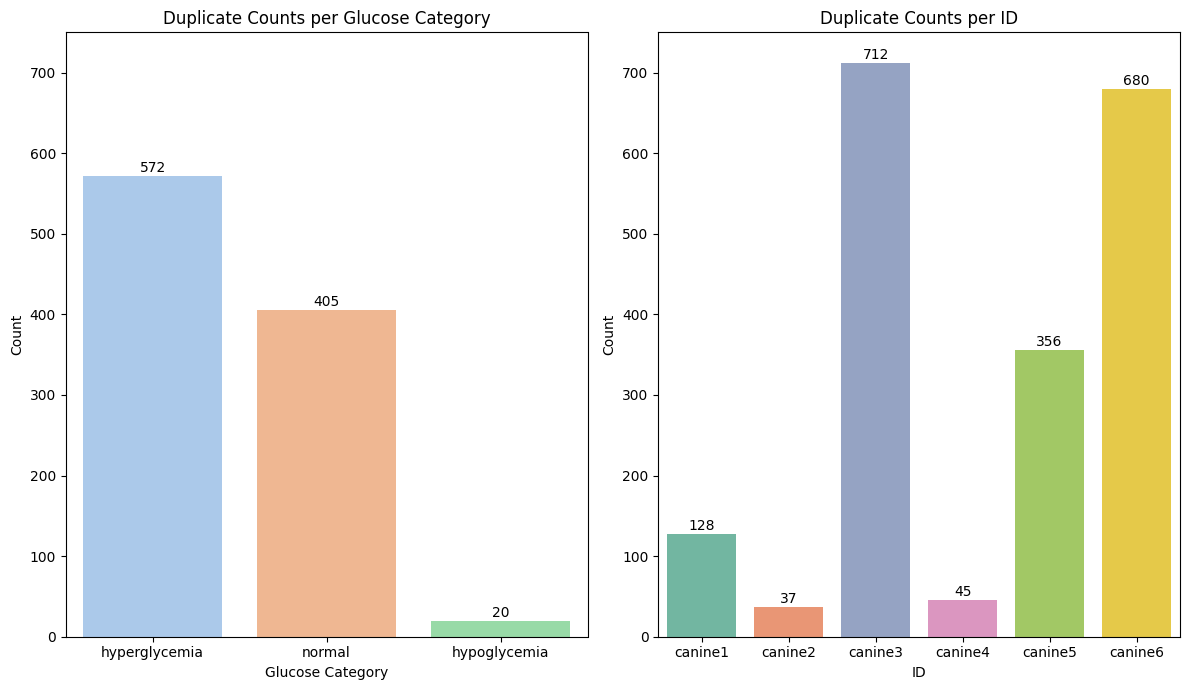

In [81]:
duplicate_counts = combined_df[combined_df.duplicated(subset = ["ID", "timestamp"])]["glucose_category"].value_counts()

duplicate_by_ID = combined_df[combined_df.duplicated(subset = ["ID", "timestamp"], keep = False)].groupby("ID").size()

print(f"Total number of duplicates: {duplicate_counts.sum()}")

print("--"*80)

fig, axes = plt.subplots(1, 2, figsize = (12, 7))

# duplicates by glucose category
ax1 = sns.barplot(
    ax = axes[0],
    data = duplicate_counts.reset_index(name = "count"),
    x = "glucose_category",
    y = "count",
    hue = "glucose_category",
    palette = "pastel"
)

for p in ax1.patches:
  height = p.get_height()
  ax1.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
)

ax1.set_title("Duplicate Counts per Glucose Category")
ax1.set_xlabel("Glucose Category")
ax1.set_ylabel("Count")
ax1.set_ylim(0, 750)


ax2 = sns.barplot(
    ax = axes[1],
    data = duplicate_by_ID.reset_index(name = "count"),
    x = "ID",
    y = "count",
    hue = "ID",
    palette = "Set2"
)

for p in ax2.patches:
  height = p.get_height()
  ax2.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
)

ax2.set_title("Duplicate Counts per ID")
ax2.set_xlabel("ID")
ax2.set_ylabel("Count")
ax2.set_ylim(0, 750)

plt.tight_layout()

## ⭐ Removing Duplicates
: Prioritzing hypoglycemic events

👉 After removing 997 duplicates, we are left with **31,899 rows**

In [82]:
dup_removed = (
    combined_df
    # sort time and glucose levels
    .sort_values(["ID", "timestamp", "glucose"])

    # get only the first observation such that we are getting the lowest value for glucose level with the same timestamp
    .drop_duplicates(subset = ["ID", "timestamp"], keep = "first")
    .reset_index(drop = True)
)

In [85]:
# check that there are no duplicates now
dup_removed[dup_removed.duplicated(subset = ["ID", "timestamp"])]

,ID,timestamp,glucose,glucose_category,normal_range


In [83]:
print(f"Shape of dataframe before removing duplicates: {combined_df.shape}")
print(f"Shape of dataframe after removing duplicates: {dup_removed.shape}")

Shape of dataframe before removing duplicates: (32896, 5)
Shape of dataframe after removing duplicates: (31899, 5)


---
# 🔆 Splitting Data
## ⭐ Understanding distribution of gaps

### Adding gap_min
: gap in minutes

In [86]:
gap_df = dup_removed.copy()
gap_df["gap_min"] = (
    gap_df
    .groupby("ID")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

The first row for each ID has NaN for gap_min

In [88]:
gap_df.groupby("ID").head(2)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0
3039,canine2,2025-04-09 12:56:00,308.0,hyperglycemia,False,NaN
3040,canine2,2025-04-09 13:11:00,274.0,hyperglycemia,False,15.0
4028,canine3,2025-04-12 19:03:00,500.0,hyperglycemia,False,NaN
4029,canine3,2025-04-12 19:06:00,500.0,hyperglycemia,False,3.0
9635,canine4,2025-03-30 13:38:00,200.0,normal,True,NaN
9636,canine4,2025-03-30 13:53:00,177.0,normal,True,15.0
12082,canine5,2025-03-22 17:43:00,478.0,hyperglycemia,False,NaN
12083,canine5,2025-03-22 17:44:00,469.0,hyperglycemia,False,1.0


#### Statistics of gap_min for each ID

In [92]:
gap_count = gap_df.groupby("ID")["gap_min"].agg(["min", "max", "median", "std", "count"]).reset_index()
gap_count

,ID,min,max,median,std,count
0,canine1,1.0,12641.0,15.0,256.460087,3038
1,canine2,1.0,285.0,15.0,12.766598,988
2,canine3,1.0,238532.0,15.0,3201.908022,5606
3,canine4,1.0,483.0,15.0,21.050015,2446
4,canine5,1.0,273825.0,15.0,3571.168487,5882
5,canine6,1.0,1445.0,15.0,30.458660,13933


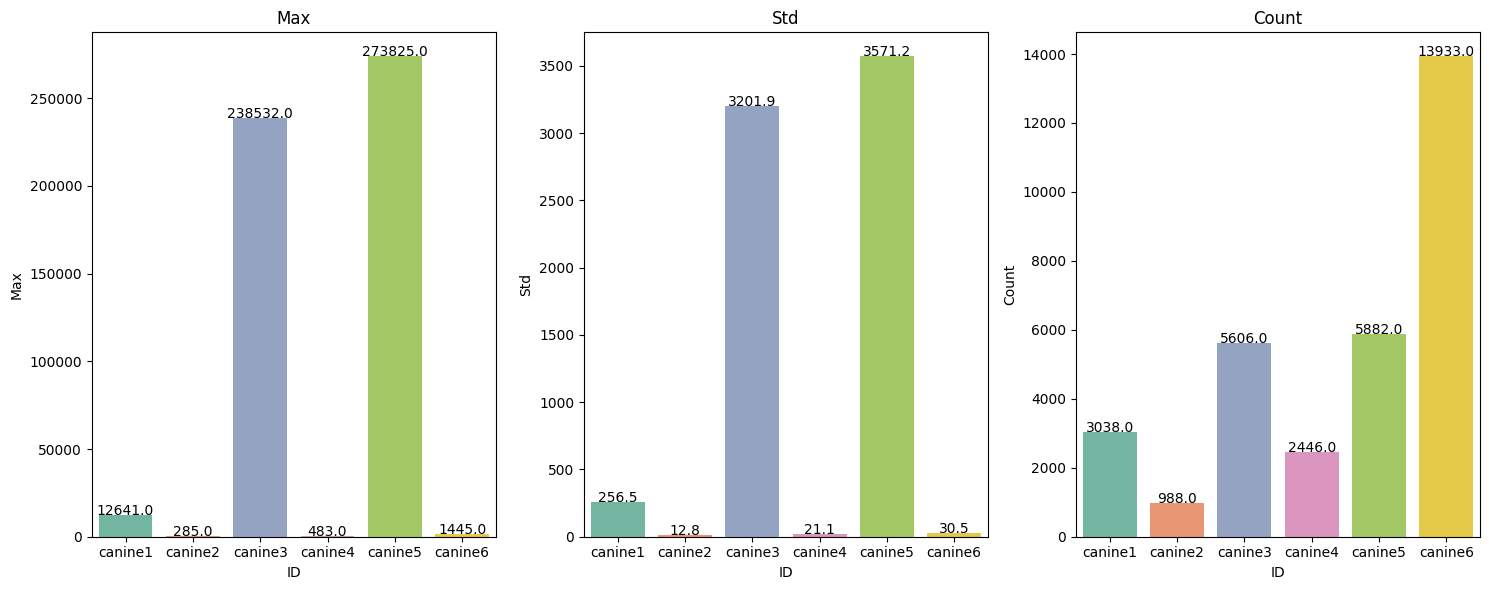

In [105]:
stats = ["max", "std", "count"]

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 6), sharey = False)

axes = axes.flatten()

for ax, stat in zip(axes, stats):
  sns.barplot(
      data = gap_count,
      x = "ID",
      y = stat,
      ax = ax,
      hue = "ID",
      palette = "Set2"
  )
  # labeling
  for p in ax.patches:
    height = p.get_height()
    ax.text(
      x = p.get_x() + p.get_width()/2,
      y = height,
      s = f"{height:.1f}",
      ha = "center"
      )

  ax.set_title(stat.capitalize())
  ax.set_xlabel("ID")
  ax.set_ylabel(stat.capitalize())

plt.tight_layout()
plt.show()


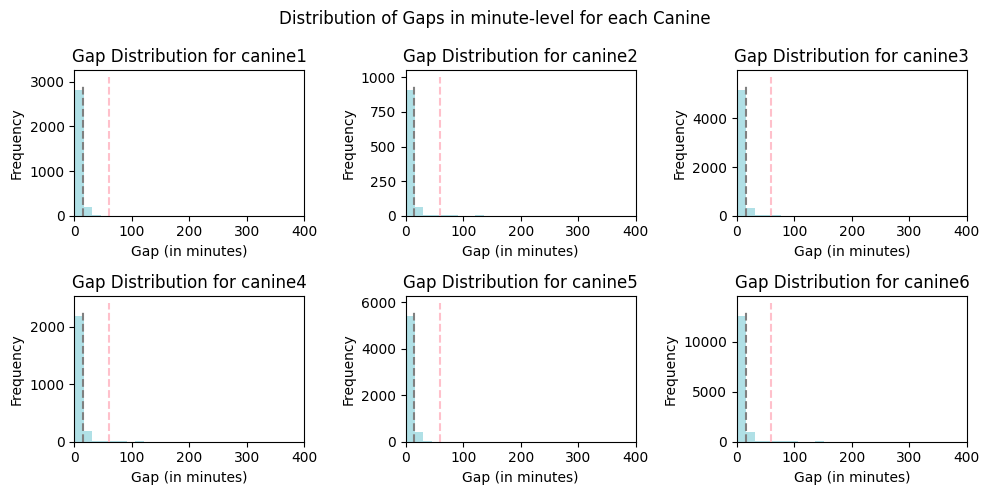

In [111]:
import numpy as np

unique_ids = gap_df['ID'].unique()
n = len(unique_ids)

cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize = (10, 5))
axes = axes.flatten()

for i, id in enumerate(unique_ids):

    df = gap_df[gap_df['ID'] == id]

    # Calculate bin edges to achieve a bin width of 5
    min_val = df["gap_min"].min()
    max_val = df["gap_min"].max()
    bins = np.arange(min_val, max_val + 15, 15)

    axes[i].hist(df["gap_min"], bins = bins, color = "powderblue")
    axes[i].set_xlabel("Gap (in minutes)")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Gap Distribution for {id}")
    axes[i].set_xlim(0, 400)
    axes[i].vlines(x = 15, ymin = 0, ymax = axes[i].get_ylim()[1], linestyle = "--", color = "grey")
    axes[i].vlines(x = 60, ymin = 0, ymax = axes[i].get_ylim()[1], linestyle = "--", color = "pink")

plt.suptitle("Distribution of Gaps in minute-level for each Canine")
plt.tight_layout()
plt.show()

### ⭐ Splitting data with gaps of 60 minutes or greater

In [135]:
large_gap = gap_df[gap_df["gap_min"] >= 60].copy()
print("Statistics of large gaps ≥ 60 minutes by ID:")
large_gap.groupby("ID")["gap_min"].describe()

Statistics of large gaps ≥ 60 minutes by ID:


,count,mean,std,min,25%,50%,75%,max
ID,,,,,,,,
canine1,24.0,1239.833333,2668.554529,72.0,131.75,215.0,752.75,12641.0
canine2,12.0,104.083333,63.100869,60.0,71.75,77.5,122.75,285.0
canine3,76.0,3813.618421,27417.562916,60.0,76.00,120.5,230.50,238532.0
canine4,43.0,141.418605,91.510143,60.0,75.50,106.0,181.00,483.0
canine5,18.0,15772.388889,64417.882739,60.0,85.50,195.0,450.50,273825.0
canine6,271.0,161.479705,152.309184,60.0,80.50,116.0,180.50,1445.0


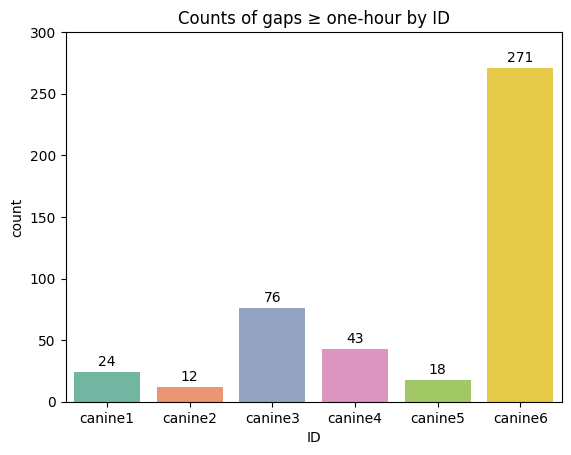

In [133]:
large_df = large_gap.groupby("ID").size().reset_index(name = "count")

ax = sns.barplot(
    data = large_df,
    x = "ID",
    y = "count",
    hue = "ID",
    palette = "Set2"
    )

for p in ax.patches:
    height = p.get_height()
    ax.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
      )
plt.ylim(0, 300)
plt.title("Counts of gaps ≥ one-hour by ID")
plt.show()


#### ❗Setting threshold and adding split_flags

* we set threshold as 60 minutes

In [137]:
max_gap = 60

In [207]:
def add_split_flags(df, max_gap = max_gap):

  df = df.copy()

  df = df.sort_values(["ID", "timestamp"])

  # adding flags for making splits
  df["split_flag"] = (
      (df["gap_min"] >= max_gap) | (df["gap_min"].isna())
  )

  df["sub_id"] = (
      df
      .groupby("ID")["split_flag"]
      .cumsum()
      .astype(str)
      .str.zfill(3)
  )

  df["split_id"] = (
      df["ID"] + "-" + df["sub_id"]
  )

  # df = df.drop(columns = ["sub_id"])

  return df

In [208]:
gap_split = add_split_flags(gap_df, max_gap)

gap_split.groupby("ID").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,split_id,sub_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,canine1-001,001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,canine1-001,001
3039,canine2,2025-04-09 12:56:00,308.0,hyperglycemia,False,NaN,True,canine2-001,001
3040,canine2,2025-04-09 13:11:00,274.0,hyperglycemia,False,15.0,False,canine2-001,001


In [160]:
print(f"Number of groups: {gap_split["split_id"].nunique()}")

split_counts = gap_split.groupby("split_id")["timestamp"].agg("count").reset_index(name = "Observations")
display(split_counts.describe())

Number of groups: 450


,Observations
count,450.000000
mean,70.886667
std,126.526204
min,1.000000
25%,6.000000
50%,31.000000
75%,80.750000
max,945.000000


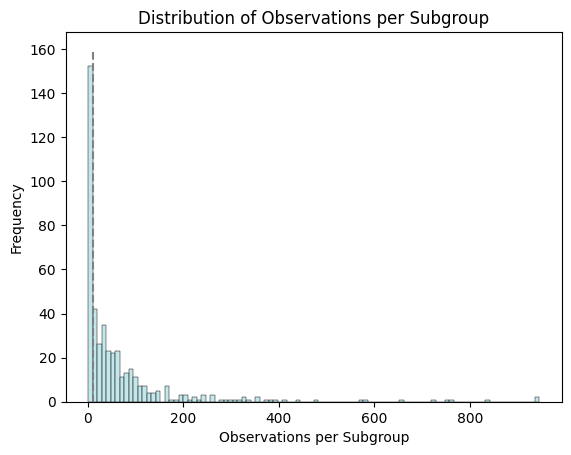

In [161]:
sns.histplot(
    data = split_counts,
    x = "Observations",
    bins = 100,
    color = "powderblue"
)

plt.xlabel("Observations per Subgroup")
plt.ylabel("Frequency")
plt.title("Distribution of Observations per Subgroup")
plt.vlines(x = 11, ymin = 0, ymax = plt.ylim()[1], linestyle = "--", color = "grey")
plt.show()

#### ⭐ Removing subgroups with observations less than 11

* There are a total of 152 subgroups with observations less than 11 among 450 sub-groups
* These subgroups account for approximately 34% of the total number of sub-groups
* The number of observations that belong to these groups are 592, which is 2% of the total observation

In [172]:
print(f"Number of Subgroups with observations less than 11: {split_counts[split_counts["Observations"] < 11]["Observations"].count()}")
print(f"Proportion of Subgroups with observations less than 11: {split_counts[split_counts["Observations"] < 11]["Observations"].count()/split_counts["Observations"].count():.2f}")
print(f"Number of Observations that belong to these subgroups: {split_counts[split_counts["Observations"] < 11]["Observations"].sum()}")
print(f"Proportion of Observations that will be removed: {split_counts[split_counts["Observations"] < 11]["Observations"].sum()/split_counts["Observations"].sum():.2f}")


Number of Subgroups with observations less than 11: 152
Proportion of Subgroups with observations less than 11: 0.34
Number of Observations that belong to these subgroups: 592
Proportion of Observations that will be removed: 0.02


In [174]:
def remove_small_subgroup(df, split_threshold):
  segment_counts = (
      df
      .groupby("split_id", sort = False)["timestamp"]
      .agg("count")
  )

  valid_segments = segment_counts[segment_counts >= split_threshold].index

  filtered_df = df[df["split_id"].isin(valid_segments)]

  return filtered_df

#### ❗Split threshold = 11

In [175]:
split_threshold = 11

In [185]:
filtered_df = remove_small_subgroup(gap_split, split_threshold = split_threshold)
print(f"Number of observations after filtering: {filtered_df.shape[0]}")

Number of observations after filtering: 31307


In [184]:
filtered_split = filtered_df.groupby("split_id")["timestamp"].agg("count").reset_index(name = "Observations")
print(f"Number of subgroups after filtering: {filtered_split.shape[0]}")
display(filtered_split.describe())

Number of subgroups after filtering: 298


,Observations
count,298.000000
mean,105.057047
std,143.977341
min,11.000000
25%,31.000000
50%,58.000000
75%,108.000000
max,945.000000


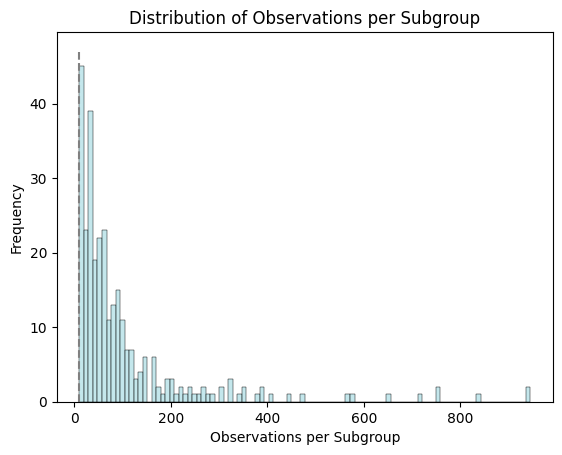

In [182]:
sns.histplot(
    data = filtered_split,
    x = "Observations",
    bins = 100,
    color = "powderblue"
)

plt.xlabel("Observations per Subgroup")
plt.ylabel("Frequency")
plt.title("Distribution of Observations per Subgroup")
plt.vlines(x = 11, ymin = 0, ymax = plt.ylim()[1], linestyle = "--", color = "grey")
plt.show()

#### Re-assigning ID to account for omitted sub-groups in between
* check the number of split_ids and the last split_id to ensure that the split_ids are re-assigned properly

In [209]:
cleaned_split = add_split_flags(filtered_df, max_gap)
display(cleaned_split.groupby("ID")["split_id"].nunique())
display(cleaned_split.groupby("ID")["split_id"].tail(1))
display(cleaned_split.groupby("split_id").head(2).head(10))

,split_id
ID,
canine1,23
canine2,8
canine3,48
canine4,24
canine5,19
canine6,176


,split_id
3038,canine1-023
4027,canine2-008
9621,canine3-048
12081,canine4-024
17964,canine5-019
31898,canine6-176


,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,split_id,sub_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,canine1-001,001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,canine1-001,001
95,canine1,2025-11-02 07:54:00,450.0,hyperglycemia,False,233.0,True,canine1-002,002
96,canine1,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0,False,canine1-002,002
226,canine1,2025-11-04 20:57:00,500.0,hyperglycemia,False,2726.0,True,canine1-003,003
227,canine1,2025-11-04 20:59:00,500.0,hyperglycemia,False,2.0,False,canine1-003,003
702,canine1,2025-11-09 01:59:00,237.0,normal,True,72.0,True,canine1-004,004
703,canine1,2025-11-09 02:14:00,245.0,normal,True,15.0,False,canine1-004,004
761,canine1,2025-11-09 16:54:00,259.0,hyperglycemia,False,140.0,True,canine1-005,005
762,canine1,2025-11-09 17:09:00,262.0,hyperglycemia,False,15.0,False,canine1-005,005


# 🔆 Final cleaning

* recalculating the gap_min
* changing the ID to reflect split_id

In [220]:
final_df = cleaned_split.sort_values(by=["ID", "sub_id", "timestamp"])
final_df.groupby("split_id").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,split_id,sub_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,canine1-001,001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,canine1-001,001
95,canine1,2025-11-02 07:54:00,450.0,hyperglycemia,False,233.0,True,canine1-002,002
96,canine1,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0,False,canine1-002,002


In [221]:
# recalculate gap_min
final_df["gap_min"] = (
    final_df
    .groupby("split_id")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

final_df.groupby("split_id").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,split_id,sub_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,canine1-001,001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,canine1-001,001
95,canine1,2025-11-02 07:54:00,450.0,hyperglycemia,False,NaN,True,canine1-002,002
96,canine1,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0,False,canine1-002,002


In [222]:
# now clean up the columns that we are not going to use and reassign IDs as split_ids
final_df["ID"] = final_df["split_id"]

final_df = final_df.drop(columns = ["split_id", "split_flag", "sub_id"])

final_df.groupby("ID").head(2).head(10)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0
95,canine1-002,2025-11-02 07:54:00,450.0,hyperglycemia,False,NaN
96,canine1-002,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0
226,canine1-003,2025-11-04 20:57:00,500.0,hyperglycemia,False,NaN
227,canine1-003,2025-11-04 20:59:00,500.0,hyperglycemia,False,2.0
702,canine1-004,2025-11-09 01:59:00,237.0,normal,True,NaN
703,canine1-004,2025-11-09 02:14:00,245.0,normal,True,15.0
761,canine1-005,2025-11-09 16:54:00,259.0,hyperglycemia,False,NaN
762,canine1-005,2025-11-09 17:09:00,262.0,hyperglycemia,False,15.0


# 🔆 Saving data files into .csv and .pkl

In [223]:
# saving to .csv file in case you want to save the file in your directory for easier loading

# Ainsley
# out_dir =

# Ci
# out_dir =

# WooJung
out_dir = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228"

final_df.to_csv(out_dir + "/final_df.csv", index = False)

print("final_df in .csv format saved in:", out_dir)

final_df in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228


In [225]:
# saving to .pkl file in case you want to save the files in your directory for easier loading

# Ainsley
# out_dir =

# Ci
# out_dir =

# WooJung
out_dir = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228"

final_df.to_pickle(out_dir + "/final_df.pkl")

print("final_df in .pkl format saved in:", out_dir)

final_df in .pkl format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228
